In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import os
import cv2
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import xml.etree.ElementTree as ET
import shutil
import json
import numpy as np
from PIL import Image, ImageOps, ImageDraw

In [ ]:
original_data_path = Path('/content/drive/MyDrive/dane_detekcja_pojazdow/EAGLE_Dataset_public')
edit_data_path = Path('/content/drive/MyDrive/dane_detekcja_pojazdow/EAGLE_Dataset_public_edit')

subfolders_names = ['Train', 'Test', 'Val']
edit_subfolders_names = ['train', 'test', 'val']


# Funkcja konwertująca współrzędne z xml na format yolo

In [ ]:
def convert_object_from_pts_to_yolo_obb_line(pts_elements, deleted_element, imagesize_element, vertical_image=False, class_index=0):
    """
    Konwertuje jeden obiekt na linię YOLO OBB na podstawie listy tagów <pt>.
    Zakłada, że indeky narożników to: 0, 1, 3, 4.

    Argumenty:
    pts_elements (list): Lista elementów ET.Element reprezentujących <pt>.
    deleted_element (ET.Element): Element XML reprezentujący <deleted>.
    imagesize_element (ET.Element): Element XML reprezentujący <imagesize>.
    vertical_image (bool): Czy obraz jest poziomym (domyślnie False).
    class_index (int): Indeks klasy.

    Zwraca:
    string: Pojedyncza linia gotowa do zapisu w pliku .txt lub None w razie błędu.
    """
    try:
        if deleted_element is not None and deleted_element.text == '1':
            return None # Pomijamy usunięte obiekty

        # 1. Pobierz wymiary obrazu do normalizacji
        img_width = float(imagesize_element.find('ncols').text)
        img_height = float(imagesize_element.find('nrows').text)

        # 2. Wyciągnij współrzędne x, y z pierwszych 4 tagów <pt>
        x1 = float(pts_elements[0].find('x').text)
        y1 = float(pts_elements[0].find('y').text)

        x2 = float(pts_elements[1].find('x').text)
        y2 = float(pts_elements[1].find('y').text)

        x3 = float(pts_elements[3].find('x').text)
        y3 = float(pts_elements[3].find('y').text)

        x4 = float(pts_elements[4].find('x').text)
        y4 = float(pts_elements[4].find('y').text)

        # 3. Normalizuj współrzędne
        x1_norm = x1 / img_width
        y1_norm = y1 / img_height
        x2_norm = x2 / img_width
        y2_norm = y2 / img_height
        x3_norm = x3 / img_width
        y3_norm = y3 / img_height
        x4_norm = x4 / img_width
        y4_norm = y4 / img_height

        # 4. Sformatuj linię wyjściową
        if not vertical_image:
          yolo_line = (
              f"{class_index} "
              f"{x1_norm:.6f} {y1_norm:.6f} "
              f"{x2_norm:.6f} {y2_norm:.6f} "
              f"{x3_norm:.6f} {y3_norm:.6f} "
              f"{x4_norm:.6f} {y4_norm:.6f}"
          )
        else:
          x1_norm = 1 - x1_norm
          x2_norm = 1 - x2_norm
          x3_norm = 1 - x3_norm
          x4_norm = 1 - x4_norm

          yolo_line = (
              f"{class_index} "
              f"{y1_norm:.6f} {x1_norm:.6f} "
              f"{y2_norm:.6f} {x2_norm:.6f} "
              f"{y3_norm:.6f} {x3_norm:.6f} "
              f"{y4_norm:.6f} {x4_norm:.6f}"
          )

        return yolo_line

    except Exception as e:
        print(pts_elements)
        print(f"BŁĄD podczas konwersji obiektu z <pt>: {e}")
        return None

def convert_object_to_yolo_obb_line(object_element, imagesize_element, class_index=0):
    """
    Konwertuje jeden obiekt <object> z XML na pojedynczą linię formatu YOLO OBB.

    Argumenty:
    object_element (ET.Element): Element XML reprezentujący <object>.
    imagesize_element (ET.Element): Element XML reprezentujący <imagesize>.
    class_index (int): Indeks klasy (domyślnie 0, jak prosiłeś).

    Zwraca:
    string: Pojedyncza linia gotowa do zapisu w pliku .txt lub None w razie błędu.
    """
    try:
        deleted = object_element.find('deleted')
        if deleted is not None and deleted.text == '1':
            return None # Pomijamy usunięte obiekty

        # 1. Pobierz wymiary obrazu do normalizacji
        # <ncols> to szerokość (width)
        img_width = float(imagesize_element.find('ncols').text)
        # <nrows> to wysokość (height)
        img_height = float(imagesize_element.find('nrows').text)

        # 2. Znajdź <bndbox> wewnątrz obiektu
        bndbox = object_element.find('bndbox')

        # 3. Wyciągnij 4 punkty narożne (są to wartości w pikselach)
        x1 = float(bndbox.find('x1').text)
        y1 = float(bndbox.find('y1').text)
        x2 = float(bndbox.find('x2').text)
        y2 = float(bndbox.find('y2').text)
        x3 = float(bndbox.find('x3').text)
        y3 = float(bndbox.find('y3').text)
        x4 = float(bndbox.find('x4').text)
        y4 = float(bndbox.find('y4').text)

        # 4. Normalizuj współrzędne (podziel przez wymiary obrazu)
        # (Format YOLO oczekuje wartości znormalizowanych w zakresie [0, 1])
        x1_norm = x1 / img_width
        y1_norm = y1 / img_height
        x2_norm = x2 / img_width
        y2_norm = y2 / img_height
        x3_norm = x3 / img_width
        y3_norm = y3 / img_height
        x4_norm = x4 / img_width
        y4_norm = y4 / img_height

        # 5. Sformatuj linię wyjściową (używamy 6 miejsc po przecinku dla precyzji)
        yolo_line = (
            f"{class_index} "
            f"{x1_norm:.6f} {y1_norm:.6f} "
            f"{x2_norm:.6f} {y2_norm:.6f} "
            f"{x3_norm:.6f} {y3_norm:.6f} "
            f"{x4_norm:.6f} {y4_norm:.6f}"
        )

        return yolo_line
    except Exception as e:
        print(f"BŁĄD podczas konwersji obiektu: {e}")
        return None

Uruchamiam test funkcji konwertującej...

Testuję na pliku: 2008-11-28-Muenchen-Verkehr-mitte-yp3x0909.xml
--- Dane wejściowe (z XML) ---
Rozmiar obrazu (W x H): 4992 x 3328
Nazwa obiektu: lkw
Oryginalne x1, y1: (132.72934441384788, 1801.7618247559801)

--- Wynik konwersji (Format YOLO OBB) - pierwsza funkcja ---
0 0.026588 0.541395 0.036863 0.540455 0.038562 0.542768 0.037063 0.545374

--- Wynik konwersji (Format YOLO OBB) - druga funkcja ---
0 0.026588 0.541395 0.036863 0.540455 0.037063 0.545374 0.026788 0.546314

Wyświetlam: [Wynik funkcji 1 (Niebieski)] --- [Wynik funkcji 2 (Czerwony)]


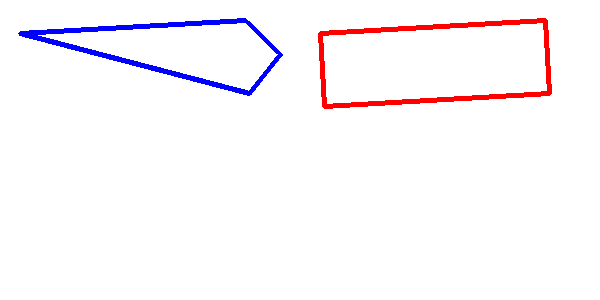

In [ ]:
print("Uruchamiam test funkcji konwertującej...")

# Używamy ścieżek zdefiniowanych w komórce 3
# original_data_path = Path('/content/drive/MyDrive/dane_detekcja_pojazdow/EAGLE_Dataset_public')
# subfolders_names = ['Train', 'Test', 'Val']

# 1. Zbuduj ścieżkę do folderu z etykietami XML w zbiorze 'Train'
xml_dir_path = original_data_path / subfolders_names[0] / 'label_xmls'

# 2. Znajdź wszystkie pliki XML w tym folderze
all_xml_files = list(xml_dir_path.glob('*.xml'))

# 3. Wybierz pierwszy plik z listy
first_xml_file = all_xml_files[0]
print(f"\nTestuję na pliku: {first_xml_file.name}")

try:
    # 4. Sparsuj plik XML
    tree = ET.parse(first_xml_file)
    root = tree.getroot()

    # 5. Znajdź elementy, których potrzebuje nasza funkcja
    imagesize_elem = root.find('imagesize')
    first_object_elem = root.find('object') # Znajdź pierwszy tag <object>

    # elementy do drugiej funkcji konwertującej
    pts_elements = first_object_elem.findall('pt')

    if imagesize_elem is not None and first_object_elem is not None:

        # 6. Uruchom naszą funkcję konwertującą
        yolo_line = convert_object_to_yolo_obb_line(
            first_object_elem,
            imagesize_elem,
            class_index=0
        )

        # 7. Uruchamiam drugą funkcję konwertującą
        yolo_line_2 = convert_object_from_pts_to_yolo_obb_line(
            pts_elements,
            first_object_elem.find('deleted'),
            imagesize_elem,
            class_index=0
        )

        # 8. Wyświetl wyniki do weryfikacji
        print("--- Dane wejściowe (z XML) ---")
        img_w = imagesize_elem.find('ncols').text
        img_h = imagesize_elem.find('nrows').text
        obj_name = first_object_elem.find('name').text
        print(f"Rozmiar obrazu (W x H): {img_w} x {img_h}")
        print(f"Nazwa obiektu: {obj_name}")
        print(f"Oryginalne x1, y1: ({first_object_elem.find('bndbox/x1').text}, {first_object_elem.find('bndbox/y1').text})")

        print("\n--- Wynik konwersji (Format YOLO OBB) - pierwsza funkcja ---")
        print(yolo_line)

        print("\n--- Wynik konwersji (Format YOLO OBB) - druga funkcja ---")
        print(yolo_line_2)

        # Tutaj ustawiasz, jak duże ma być docelowe płótno
        STAŁY_ROZMIAR_PLOTNA = 300
        # Ustawia, ile marginesu ma być dookoła kształtu (wewnątrz płótna)
        PADDING = 40
        # ----------------------------------------

        # 1. Pobierz oryginalne wymiary obrazu (już je mamy)
        img_w = int(img_w)
        img_h = int(img_h)

        # 2. Funkcja pomocnicza do ekstrakcji i denormalizacji punktów
        def get_denormalized_points(yolo_line_str, h, w):
            """Zwraca tablicę numpy [4, 2] z punktami (x, y) w pikselach."""
            parts = yolo_line_str.split()
            coords_normalized = [float(p) for p in parts[1:]]
            points = []
            for i in range(0, 8, 2):
                px = int(coords_normalized[i] * w)
                py = int(coords_normalized[i+1] * h)
                points.append([px, py])
            return np.array(points, dtype=np.int32)

        # 3. Pobierz punkty w pikselach dla obu ramek
        points_1 = get_denormalized_points(yolo_line, img_h, img_w)
        points_2 = get_denormalized_points(yolo_line_2, img_h, img_w)

        # 4. Funkcja do "przesunięcia" kształtu do rogu (0,0)
        def normalize_shape_to_origin(points):
            min_x = np.min(points[:, 0])
            min_y = np.min(points[:, 1])
            translated_points = points.copy()
            translated_points[:, 0] -= min_x
            translated_points[:, 1] -= min_y
            shape_w = np.max(translated_points[:, 0])
            shape_h = np.max(translated_points[:, 1])
            return translated_points, shape_w, shape_h

        # 5. Znormalizuj (przesuń) oba kształty
        shape_1_points, shape_1_w, shape_1_h = normalize_shape_to_origin(points_1)
        shape_2_points, shape_2_w, shape_2_h = normalize_shape_to_origin(points_2)

        # 6. ZNAJDŹ WSPÓŁCZYNNIK SKALOWANIA
        # Znajdź największy wymiar spośród obu kształtów
        max_shape_dimension = max(shape_1_w, shape_1_h, shape_2_w, shape_2_h)

        # Oblicz rozmiar obszaru, w którym chcemy rysować
        drawable_area_size = STAŁY_ROZMIAR_PLOTNA - PADDING

        # Oblicz współczynnik skalowania, aby dopasować największy kształt
        if max_shape_dimension == 0:
            scale_factor = 1 # Unikaj dzielenia przez zero
        else:
            scale_factor = drawable_area_size / max_shape_dimension

        # 7. Stwórz dwa nowe, białe płótna o STAŁYM ROZMIARZE
        canvas_h = STAŁY_ROZMIAR_PLOTNA
        canvas_w = STAŁY_ROZMIAR_PLOTNA

        canvas_1 = np.ones((canvas_h, canvas_w, 3), dtype=np.uint8) * 255
        canvas_2 = np.ones((canvas_h, canvas_w, 3), dtype=np.uint8) * 255

        # 8. Funkcja do rysowania przeskalowanego kształtu
        def draw_scaled_shape(canvas, shape_points, scale, offset_xy, color):
            # Skaluj punkty
            scaled_points = (shape_points * scale).astype(np.int32)

            # Przesuń o margines (połowa PADDING)
            translated_points = scaled_points + offset_xy

            # Przygotuj do cv2
            cv_points = translated_points.reshape((-1, 1, 2))

            # Rysuj
            cv2.polylines(canvas, [cv_points], isClosed=True, color=color, thickness=3)

        # Oblicz offset (połowa paddingu)
        offset = PADDING // 2

        # 9. Narysuj oba kształty
        draw_scaled_shape(canvas_1, shape_1_points, scale_factor, offset, (255, 0, 0)) # Niebieski
        draw_scaled_shape(canvas_2, shape_2_points, scale_factor, offset, (0, 0, 255)) # Czerwony

        # 10. Połącz i wyświetl (nie trzeba już skalować)
        combined_image = np.hstack((canvas_1, canvas_2))

        print("\nWyświetlam: [Wynik funkcji 1 (Niebieski)] --- [Wynik funkcji 2 (Czerwony)]")
        cv2_imshow(combined_image)

    else:
        print("BŁĄD: W pliku brakuje tagu <imagesize> lub <object>")

except ET.ParseError as e:
    print(f"BŁĄD parsowania pliku {first_xml_file.name}: {e}")

# Funkcje i struktury do rejestracji braków danych

In [ ]:
files_bndbox_not_found = {
    "test": set(),
    "train": set(),
    "val": set()
}

files_pts_not_found = {
    "test": set(),
    "train": set(),
    "val": set()
}

files_any_coordinates_missing = {
    "test": set(),
    "train": set(),
    "val": set()
}

number_of_labels_to_check = {
    "test": 0,
    "train": 0,
    "val": 0
}

def check_for_missing_coordinates(
    object_element,
    pts_elements,
    file_xml,
    struct_bndbox_not_found = files_bndbox_not_found,
    struct_any_coordinates_missing = files_any_coordinates_missing,
    struct_pts_not_found = files_pts_not_found
    ):
  not_missing_bndbox = True
  not_missing_pts = True

  key_dict = str(file_xml.parent.parent.name.lower())

  if object_element is None:
    struct_bndbox_not_found[key_dict].add(file_xml.name)
    not_missing_bndbox = False

  bndbox = object_element.find('bndbox')
  if bndbox is None:
    struct_bndbox_not_found[key_dict].add(file_xml.name)
    not_missing_bndbox = False

  if any(pt is None for pt in pts_elements) or (len(pts_elements) == 0):
    struct_pts_not_found[key_dict].add(file_xml.name)
    not_missing_pts = False

  if not_missing_bndbox:
    return "not_missing_bndbox"
  elif (not not_missing_bndbox) and not_missing_pts:
    return "not_missing_pts"
  else:
    struct_any_coordinates_missing[key_dict].add(file_xml.name)
    return "missing_both"


# Funkcja przetwarzająca cały plik

In [ ]:
def process_xml_to_yolo_txt(xml_file_path, target_txt_path, vertical_image: bool):
    """
    Parsuje pojedynczy plik XML, konwertuje WSZYSTKIE obiekty
    i zapisuje je do nowego pliku .txt w formacie YOLO OBB.

    Argumenty:
    xml_file_path (Path): Ścieżka do oryginalnego pliku .xml
    target_txt_path (Path): Ścieżka, gdzie ma być zapisany nowy plik .txt
    vertical_image (bool): Czy obraz jest poziomem (domyślnie False)

    Zwraca:
    bool: True jeśli się udało, False jeśli wystąpił błąd.
    """
    try:
        # 1. Sparsuj plik XML
        tree = ET.parse(xml_file_path)
        root = tree.getroot()

        # 2. Znajdź <imagesize> (potrzebne do normalizacji)
        imagesize_elem = root.find('imagesize')
        if imagesize_elem is None:
            print(f"Ostrzeżenie: Brak <imagesize> w {xml_file_path.name}. Pomijam plik.")
            return False

        # 3. Znajdź WSZYSTKIE obiekty
        all_objects = root.findall('object')

        # Lista na wszystkie wiersze (ramki) dla tego obrazu
        yolo_lines = []

        # 4. Przejdź w pętli przez wszystkie znalezione obiekty
        for obj_elem in all_objects:

            # sprawdź czy nie brakuje danych
            check_result = check_for_missing_coordinates(
                obj_elem,
                obj_elem.findall('pt'),
                xml_file_path
            )

            if check_result in ("not_missing_pts", "not_missing_bndbox"):
                line = convert_object_from_pts_to_yolo_obb_line(
                    obj_elem.findall('pt'),
                    obj_elem.find('deleted'),
                    imagesize_elem,
                    vertical_image=vertical_image
                )
            else:
              line = None # aby uniknąć UnboundLocalError

            if line: # Sprawdź, czy konwersja się udała (nie zwróciła None)
                yolo_lines.append(line)

        # 6. Zapisz plik .txt, TYLKO jeśli zawiera jakieś obiekty
        if yolo_lines:
            # Upewnij się, że folder docelowy istnieje
            # (To zrobi też pętla główna, ale to jest bezpieczniejsze)
            target_txt_path.parent.mkdir(parents=True, exist_ok=True)

            # Zapisz wszystkie linie, oddzielając je znakiem nowej linii
            with open(target_txt_path, 'w') as f:
                f.write('\n'.join(yolo_lines))
            return True # Sukces
        else:
            # Plik XML był pusty (bez obiektów)
            print(f"Info: Brak obiektów w {xml_file_path.name}. Plik .txt nie został utworzony.")
            return True # Technicznie nie błąd, po prostu pusty

    except ET.ParseError as e:
        print(f"BŁĄD parsowania XML {xml_file_path.name}: {e}")
        return False
    # except Exception as e:
    #     print(f"Nieznany błąd podczas przetwarzania {xml_file_path.name}: {e} :-(")
    #     return False

# Główna pętla przetwarzająca

In [ ]:
def is_vertical_image(image_path):
    """
    Sprawdza, czy obraz jest poziomem
    """
    with Image.open(source_image_path) as img:
      img_oriented = ImageOps.exif_transpose(img)

      width, height = img_oriented.size

      if height > width:
          return True
      else:
          return False

print("Rozpoczynam pełne przetwarzanie zbioru danych...")

# Używamy ścieżek zdefiniowanych w komórce 3
# original_data_path, edit_data_path, subfolders_names, edit_subfolders_names

# Liczniki do podsumowania
total_labels_processed = 0
total_images_copied = 0

# Iteruj przez podfoldery (np. 'Train' -> 'train', 'Test' -> 'test')
for source_folder_name, target_folder_name in zip(subfolders_names, edit_subfolders_names):

    print(f"\n--- Przetwarzanie folderu: {source_folder_name} ---")

    # 1. Zdefiniuj ścieżki źródłowe
    source_label_dir = original_data_path / source_folder_name / 'label_xmls'
    source_image_dir = original_data_path / source_folder_name / 'images'

    # 2. Zdefiniuj ścieżki docelowe
    target_label_dir = edit_data_path / target_folder_name / 'labels'
    target_image_dir = edit_data_path / target_folder_name / 'images'

    # 3. Stwórz strukturę folderów docelowych (jeśli nie istnieje)
    target_label_dir.mkdir(parents=True, exist_ok=True)
    target_image_dir.mkdir(parents=True, exist_ok=True)

    print(f"Folder docelowy etykiet: {target_label_dir}")
    print(f"Folder docelowy obrazów: {target_image_dir}")

    # 4. Znajdź wszystkie pliki XML w folderze źródłowym
    xml_files = list(source_label_dir.glob('*.xml'))

    print(f"Znaleziono {len(xml_files)} plików etykiet do przetworzenia...")

    # Lokalne liczniki dla tego folderu
    labels_count = 0
    images_count = 0

    # 5. Przetwórz każdy plik XML
    for xml_file_path in xml_files:
        file_stem = xml_file_path.stem  # Nazwa pliku bez rozszerzenia

        # --- a) Skopiuj pasujący obraz ---
        # Wyszukaj obrazu o tej samej nazwie, ale dowolnym rozszerzeniu
        # (np. .JPG, .png, .jpg)
        found_images = list(source_image_dir.glob(f"{file_stem}.*"))

        is_vertical_image_ = False
        if found_images:
            source_image_path = found_images[0] # Bierzemy pierwszy pasujący
            target_image_path = target_image_dir / source_image_path.name

            is_vertical_image_ = is_vertical_image(source_image_path)

            # Kopiuj obraz (szybsze niż wczytywanie i zapisywanie)
            shutil.copy(source_image_path, target_image_path)

            images_count += 1

        else:
            print(f"Ostrzeżenie: Nie znaleziono pasującego obrazu dla {xml_file_path.name}")

        # --- b) Przetwórz etykiety ---
        target_txt_path = target_label_dir / f"{file_stem}.txt"

        if process_xml_to_yolo_txt(xml_file_path, target_txt_path, is_vertical_image_):
            labels_count += 1

        # Zapobiegaj zaśmiecaniu logów (pokaż co 100-tny plik)
        if (labels_count % 100) == 0:
            print(f"  ... przetworzono {labels_count} etykiet i skopiowano {images_count} obrazów...")

    print(f"Zakończono dla {source_folder_name}:")
    print(f"  Przetworzono etykiet: {labels_count}")
    print(f"  Skopiowano obrazów: {images_count}")

    number_of_labels_to_check[source_folder_name.lower()] = images_count

    total_labels_processed += labels_count
    total_images_copied += images_count

print("\n" + "="*30)
print("     ZAKOŃCZONO CAŁY PROCES")
print("="*30)
print(f"Łącznie przetworzonych etykiet: {total_labels_processed}")
print(f"Łącznie skopiowanych obrazów: {total_images_copied}")
print(f"\nTwój nowy, gotowy do treningu zbiór danych znajduje się w:\n{edit_data_path}")

Rozpoczynam pełne przetwarzanie zbioru danych...

--- Przetwarzanie folderu: Train ---
Folder docelowy etykiet: /content/drive/MyDrive/dane_detekcja_pojazdow/EAGLE_Dataset_public_edit/train/labels
Folder docelowy obrazów: /content/drive/MyDrive/dane_detekcja_pojazdow/EAGLE_Dataset_public_edit/train/images
Znaleziono 159 plików etykiet do przetworzenia...
  ... przetworzono 100 etykiet i skopiowano 100 obrazów...
Zakończono dla Train:
  Przetworzono etykiet: 159
  Skopiowano obrazów: 159

--- Przetwarzanie folderu: Test ---
Folder docelowy etykiet: /content/drive/MyDrive/dane_detekcja_pojazdow/EAGLE_Dataset_public_edit/test/labels
Folder docelowy obrazów: /content/drive/MyDrive/dane_detekcja_pojazdow/EAGLE_Dataset_public_edit/test/images
Znaleziono 106 plików etykiet do przetworzenia...
  ... przetworzono 100 etykiet i skopiowano 100 obrazów...
Zakończono dla Test:
  Przetworzono etykiet: 106
  Skopiowano obrazów: 106

--- Przetwarzanie folderu: Val ---
Folder docelowy etykiet: /content

# Etykiety z błędami

In [ ]:
files_bndbox_not_found

{'test': {'2007-06-17-Muenchen-HYMAP-mitte-yp3x0404.xml',
  '2007-06-23-Camargue-mitte-YP3X0010.xml',
  '2008-11-27-Muenchen-Verkehr-links-ys5z0038.xml',
  '2008-11-28-Muenchen-Verkehr-mitte-yp3x0255.xml',
  '2008-11-28-Muenchen-Verkehr-mitte-yp3x0292.xml',
  '2010-10-11-Ungarn-rechts-yr7e0151.xml',
  '2011-07-07-Tollwood--mitte-5V4B0044.xml',
  '2012-04-26-Muenchen-Tunnel_4K0G0040.xml',
  '2012-04-26-Muenchen-Tunnel_4K0G0060.xml',
  '2012-04-26-Muenchen-Tunnel_4K0G0120.xml',
  '2012-04-26-Muenchen-Tunnel_4K0G0140.xml',
  '2012-04-26-Muenchen-Tunnel_4K0G0150.xml',
  '2012-04-26-Muenchen-Tunnel_4K0G0160.xml',
  '2012-05-19-Champions-League-Final-links-F0459.xml',
  '2012-05-19-Champions-League-Final-mitte-S0075.xml',
  '2012-05-19-Champions-League-Final-mitte-S0112.xml',
  '2013-06-05-Hochwasser_dresden-mitte-N0033.xml',
  '2013-06-05-Hochwasser_dresden-mitte-N0153.xml',
  '2013-06-05-Hochwasser_dresden-mitte-N0872.xml',
  '2013-06-28-Stuttgart-Feuerwehr-mitte-N0166.xml',
  '2013-08-02-

In [ ]:
files_any_coordinates_missing

{'test': {'2007-06-17-Muenchen-HYMAP-mitte-yp3x0404.xml',
  '2007-06-23-Camargue-mitte-YP3X0010.xml',
  '2008-11-27-Muenchen-Verkehr-links-ys5z0038.xml',
  '2008-11-28-Muenchen-Verkehr-mitte-yp3x0255.xml',
  '2008-11-28-Muenchen-Verkehr-mitte-yp3x0292.xml',
  '2010-10-11-Ungarn-rechts-yr7e0151.xml',
  '2011-07-07-Tollwood--mitte-5V4B0044.xml',
  '2012-04-26-Muenchen-Tunnel_4K0G0060.xml',
  '2012-04-26-Muenchen-Tunnel_4K0G0140.xml',
  '2012-04-26-Muenchen-Tunnel_4K0G0150.xml',
  '2012-05-19-Champions-League-Final-links-F0459.xml',
  '2012-05-19-Champions-League-Final-mitte-S0075.xml',
  '2012-05-19-Champions-League-Final-mitte-S0112.xml',
  '2013-06-05-Hochwasser_dresden-mitte-N0033.xml',
  '2013-06-05-Hochwasser_dresden-mitte-N0153.xml',
  '2013-06-05-Hochwasser_dresden-mitte-N0872.xml',
  '2013-06-28-Stuttgart-Feuerwehr-mitte-N0166.xml',
  '2013-08-02-Frankfurt-mitte-4K0G0171.xml',
  '2013-08-02-Frankfurt-mitte-4K0G0185.xml',
  '2014-07-25-Chicago--links-F0019.xml',
  '2015-03-20-Karl

In [ ]:
number_of_labels_to_check

{'test': 106, 'train': 159, 'val': 53}

In [ ]:
def print_error_summary(error_files_dict, total_files_dict=number_of_labels_to_check):
    """
    Wypisuje podsumowanie błędów dla podziałów train, val i test.

    Argumenty:
    error_files_dict (dict): Słownik, którego wartościami są zbiory (set)
                             nazw plików, w których wystąpił błąd.
    total_files_dict (dict): Słownik z całkowitą liczbą plików
                             dla każdego podziału. Domyślnie używa
                             globalnej zmiennej 'number_of_labels_to_check'.
    """

    print("--- Podsumowanie Błędów Przetwarzania ---")

    # Używamy kluczy ze słownika zliczającego jako podstawy
    for split_name in total_files_dict.keys():

        # Pobierz całkowitą liczbę plików dla tego podziału
        total_count = total_files_dict.get(split_name, 0)

        # Pobierz zbiór plików z błędami (bezpiecznie, z .get())
        failed_files_set = error_files_dict.get(split_name, set())

        # Policz, ile było unikalnych plików z błędami
        failed_count = len(failed_files_set)

        # Oblicz procent
        if total_count > 0:
            percentage = (failed_count / total_count) * 100
            print(f"Split '{split_name}': {failed_count} plików z błędem / {total_count} wszystkich ({percentage:.2f}%)")
        else:
            # Unikaj dzielenia przez zero, jeśli dla splitu nie ma plików
            print(f"Split '{split_name}': 0 plików przetworzonych.")

In [ ]:
print_error_summary(files_bndbox_not_found)

--- Podsumowanie Błędów Przetwarzania ---
Split 'test': 67 plików z błędem / 106 wszystkich (63.21%)
Split 'train': 99 plików z błędem / 159 wszystkich (62.26%)
Split 'val': 36 plików z błędem / 53 wszystkich (67.92%)


In [ ]:
print_error_summary(files_any_coordinates_missing)

--- Podsumowanie Błędów Przetwarzania ---
Split 'test': 64 plików z błędem / 106 wszystkich (60.38%)
Split 'train': 94 plików z błędem / 159 wszystkich (59.12%)
Split 'val': 35 plików z błędem / 53 wszystkich (66.04%)


In [ ]:
print_error_summary(files_pts_not_found)

--- Podsumowanie Błędów Przetwarzania ---
Split 'test': 64 plików z błędem / 106 wszystkich (60.38%)
Split 'train': 94 plików z błędem / 159 wszystkich (59.12%)
Split 'val': 35 plików z błędem / 53 wszystkich (66.04%)


# Ocena wizualna

In [ ]:
def visualize_converted_boxes(image_file_name, subfolder='train'):
    """
    Wizualizuje skonwertowane ramki OBB (9-kolumnowe) na obrazie.

    Zakłada, że zmienne globalne 'data_path' i 'data_copy_path'
    są zdefiniowane poza tą funkcją.

    Argumenty:
    image_file_name (str): Nazwa pliku obrazu (np. "moj_obraz.JPG")
    subfolder (str): Podfolder, w którym jest obraz (np. 'train', 'val', 'test')
    """

    # 1. Automatycznie utwórz nazwę pliku etykiety z nazwy obrazu
    #    (np. "obraz.JPG" -> "obraz.txt")
    label_file_name = Path(image_file_name).stem + '.txt'

    # 2. Zbuduj pełne ścieżki
    image_path = edit_data_path / subfolder / 'images' / image_file_name
    new_label_path = edit_data_path / subfolder / 'labels' / label_file_name

    # 3. Sprawdź, czy pliki istnieją
    if not image_path.exists():
        print(f"BŁĄD: Nie znaleziono obrazu: {image_path}")
        return  # Zakończ funkcję

    if not new_label_path.exists():
        print(f"BŁĄD: Nie znaleziono NOWEJ etykiety: {new_label_path}")
        print("Sprawdź, czy uruchomiłeś skrypt konwertujący Krok 3.")
        return  # Zakończ funkcję

    # 4. Wczytaj obraz i etykiety (ten sam kod co poprzednio)
    print(f"Weryfikacja wizualna dla: {image_file_name} (z folderu {subfolder})")
    img = cv2.imread(str(image_path))

    if img is None:
        print(f"BŁĄD: Nie można było wczytać obrazu z {image_path}")
        return

    h, w, _ = img.shape
    boxes_drawn = 0

    with open(new_label_path, 'r') as f:
        # Pętla przez wszystkie linie
        for line in f:
            parts = line.strip().split()

            if len(parts) == 9:
                boxes_drawn += 1
                points_norm = [float(p) for p in parts[1:]]

                points_abs = []
                for i in range(0, 8, 2):
                    x_norm, y_norm = points_norm[i], points_norm[i+1]
                    x_abs, y_abs = int(x_norm * w), int(y_norm * h)
                    points_abs.append([x_abs, y_abs])

                pts_np = np.array(points_abs, dtype=np.int32).reshape((-1, 1, 2))
                cv2.polylines(img, [pts_np], isClosed=True, color=(0, 255, 0), thickness=2)

    # 5. Wyświetl wynik
    if boxes_drawn > 0:
        print(f"Narysowano {boxes_drawn} ramek.")
        cv2_imshow(img)
    else:
        print("Nie znaleziono żadnych poprawnych etykiet (9 kolumn) w pliku.")

In [ ]:
visualize_converted_boxes('2007-06-17-Muenchen-HYMAP-mitte-yp3x0404.jpg', subfolder='test')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# visualize_converted_boxes('2007-06-23-Camargue-mitte-YP3X0010.JPG', subfolder='test')

In [ ]:
visualize_converted_boxes('2015-04-09-OP-mitte-4K0G0159.JPG', subfolder='test')

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
visualize_converted_boxes('2016-08-02-wolfsburg-rechts-R0156.jpg', subfolder='val')

# Zapis obrazów z ramkami na dysk
(cel przejrzenia danych)

In [ ]:
# ścieżka do danych
draw_obb_path = Path("/content/drive/MyDrive/dane_detekcja_pojazdow/draw_obb")

# ścieżka z obrazami edit_data_path

# podfoldery
potential_incomplete = "potential_incomplete"
potential_complete = "potential_complete"

# podział folderów test, val, train
subfolders_tvt = ["test", "val", "train"]

# ścieżki do obrazów potencjalnie niekompletnych
incomplete_paths = set()
incomplete_paths_stems = set()

for k, s in files_pts_not_found.items():
  for i in s:
    stem = Path(i).stem

    incomplete_paths_stems.add(stem)

# ścieżki do obrazów potencjanie kompletnych
complete_paths = set()

for subfolder in subfolders_tvt:
  folder_path_image = edit_data_path / subfolder / "images"
  for path_image in folder_path_image.glob("*.*"):
    if path_image.stem in incomplete_paths_stems:
      incomplete_paths.add(path_image)
    else:
      complete_paths.add(path_image)

print("Liczba wszystkich obrazów: ", number_of_labels_to_check["test"] + number_of_labels_to_check["val"] + number_of_labels_to_check["train"])
print("Liczba obrazów bez ramek: ", len(incomplete_paths))
print("Liczba obrazów z ramkami: ", len(complete_paths))
print("Suma obrazów z ramkami i bez: ", len(incomplete_paths) + len(complete_paths))


Liczba wszystkich obrazów:  318
Liczba obrazów bez ramek:  193
Liczba obrazów z ramkami:  125
Suma obrazów z ramkami i bez:  318


In [ ]:
def save_image_with_obb(image_file_path, potential_complete_bool: bool):

    # Zbuduj pełne ścieżki
    image_path = image_file_path

    subfolder = image_file_path.parent.parent.name
    new_label_path = edit_data_path / subfolder / 'labels' / (image_file_path.stem + '.txt')

    # 3. Sprawdź, czy pliki istnieją
    if not image_path.exists():
        print(f"BŁĄD: Nie znaleziono obrazu: {image_path}")
        return  # Zakończ funkcję

    if not new_label_path.exists():
        print(f"BŁĄD: Nie znaleziono NOWEJ etykiety: {new_label_path}")
        print("Sprawdź, czy uruchomiłeś skrypt konwertujący Krok 3.")
        return  # Zakończ funkcję

    # 4. Wczytaj obraz i etykiety (ten sam kod co poprzednio)
    img = cv2.imread(str(image_path))

    if img is None:
        print(f"BŁĄD: Nie można było wczytać obrazu z {image_path}")
        return

    h, w, _ = img.shape
    boxes_drawn = 0

    with open(new_label_path, 'r') as f:
        # Pętla przez wszystkie linie
        for line in f:
            parts = line.strip().split()

            if len(parts) == 9:
                boxes_drawn += 1
                points_norm = [float(p) for p in parts[1:]]

                points_abs = []
                for i in range(0, 8, 2):
                    x_norm, y_norm = points_norm[i], points_norm[i+1]
                    x_abs, y_abs = int(x_norm * w), int(y_norm * h)
                    points_abs.append([x_abs, y_abs])

                pts_np = np.array(points_abs, dtype=np.int32).reshape((-1, 1, 2))
                cv2.polylines(img, [pts_np], isClosed=True, color=(0, 255, 0), thickness=2)

    # 5. Zapisz wynik
    if boxes_drawn > 0:
        if potential_complete_bool:
          save_path = draw_obb_path / potential_complete
        else:
          save_path = draw_obb_path / potential_incomplete

        save_path.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(save_path / image_file_path.name), img)
        print(f"Zapisano obraz z ramkami: {image_file_path.name}")
    else:
        print("Nie znaleziono żadnych poprawnych etykiet (9 kolumn) w pliku.")

In [ ]:
for image_path_ in complete_paths:
  save_image_with_obb(image_path_, potential_complete_bool=True)

for image_path_ in incomplete_paths:
  save_image_with_obb(image_path_, potential_complete_bool=False)

Zapisano obraz z ramkami: 2018-09-27-Baustelle_L2461.jpg
Zapisano obraz z ramkami: 2012-05-19-Champions-League-Final-links-F0891.jpg
Zapisano obraz z ramkami: 2012-04-26-Muenchen-Tunnel_4K0G0080.JPG
Zapisano obraz z ramkami: 2017-04-20-Braunschweig-Frankfurt--mitte-4K0G1292.JPG
Zapisano obraz z ramkami: 2017-07-04-München-Zentrum-links-L0136.jpg
Zapisano obraz z ramkami: 2017-07-03-Braunschweig-set1-N-4K0G0597.JPG
Zapisano obraz z ramkami: 2016-02-PHAROS_SOLOSNA-2016-03-01-Solsona-links-L0100.jpg
Zapisano obraz z ramkami: 2018-04-28-HySpex-Kaufbeuren-mitte-4K0G0165_invorstudie_aber_mit_allen_klassen.JPG
Zapisano obraz z ramkami: 2016-08-02-wolfsburg-rechts-R0030.jpg
Zapisano obraz z ramkami: 2017-04-20-Braunschweig-Frankfurt--mitte-4K0G0646.JPG
Zapisano obraz z ramkami: 2012-04-26-Muenchen-Tunnel_4K0G0051.JPG
Zapisano obraz z ramkami: 2018-10-26-Freiham-A96-original-mitte_4K0G0088.JPG
Zapisano obraz z ramkami: 2017-07-04-München-Zentrum-links-L0047.jpg
Zapisano obraz z ramkami: 2016-

# Utworzenie pliku YAML do formatu YOLO

In [ ]:
file_yaml_text = f"""
path: {edit_data_path}

train: train/images
val: val/images
test: test/images

nc: 1
names: ['vehicle']
"""

print(file_yaml_text)


path: /content/drive/MyDrive/dane_detekcja_pojazdow/EAGLE_Dataset_public_edit

train: train/images
val: val/images
test: test/images

nc: 1
names: ['vehicle']



In [ ]:
yaml_file_path = edit_data_path / 'data.yaml'

with open(yaml_file_path, 'w') as f:
    f.write(file_yaml_text)

print(f"Plik YAML został zapisany do: {yaml_file_path}")

Plik YAML został zapisany do: /content/drive/MyDrive/dane_detekcja_pojazdow/EAGLE_Dataset_public_edit/data.yaml
